### Cat vs Dog Classification Lab

Although this dataset contains only two classes, the classification problem is not trivial. Dogs and cats appear in a wide variety of breeds, sizes, fur colors, and poses. Some breeds of dogs look very similar to certain cats, especially in close-up images. Additionally, images in the dataset have different lighting conditions, backgrounds, and camera angles. Some images contain cluttered environments, while others focus only on the animal’s face. These variations increase intra-class diversity and make it difficult for a model to rely on simple patterns. Therefore, even though this is a binary classification problem, it requires learning robust and discriminative visual features.

### Data Preprocessing

All images must be resized to a fixed size because convolutional neural networks require consistent input dimensions. Without resizing, the model cannot process batches of images.

Pixel normalization is performed by dividing values by 255 so that they lie between 0 and 1. This stabilizes gradient updates during training and improves convergence.

The dataset is split into training and validation sets (80/20 split). The training set is used to learn model parameters, while the validation set evaluates generalization performance on unseen data.

In [17]:
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

data_dir = r"D:\Lexicon_Labs\Deep_Learning\Day_4"
IMG_SIZE = 128

def preprocess_and_fix_images(folder_path):
    for class_name in ["cat", "dog"]:
        class_dir = os.path.join(folder_path, class_name)
        for fname in os.listdir(class_dir):
            path = os.path.join(class_dir, fname)
            # Only process typical image files
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                print("Removing non-image file:", path)
                os.remove(path)
                continue
            try:
                img = Image.open(path)
                img.verify()  # checking if the image is broken
            except:
                print("Removing corrupted image:", path)
                os.remove(path)
                continue
            # Reopening for mode check
            img = Image.open(path)
            if img.mode != "RGB":
                print("Converting to RGB:", path)
                img = img.convert("RGB")
                img.save(path)
                
            # Resize to uniform size
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img.save(path)

preprocess_and_fix_images(data_dir)
print("Dataset cleaned, converted to RGB, and resized.")

Dataset cleaned, converted to RGB, and resized.


In [18]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Normalize 
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

# Optimize
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


### Improvement: Data Augmentation

To improve generalization, data augmentation is applied. This artificially increases dataset diversity by randomly flipping, rotating, and zooming images during training. This helps the model become more robust to variations in orientation and viewpoint.

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

### CNN Architecture

The model consists of multiple convolutional layers followed by max pooling layers. Convolutional layers extract spatial features such as edges, textures, and shapes. As the network gets deeper, the number of filters increases to capture more complex patterns.

Pooling layers reduce spatial dimensions and help the network become more robust to small translations.

Dropout is included to reduce overfitting by randomly disabling neurons during training.

The final layer contains a single neuron with a sigmoid activation function, which outputs a probability value between 0 and 1 for binary classification.

In [22]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compilation and Training

Binary crossentropy is used as the loss function because this is a binary classification task. The Adam optimizer is chosen for efficient gradient-based optimization. Both training and validation accuracy are tracked to detect overfitting or underfitting.

In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [25]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 243s 187ms/step - accuracy: 0.5913 - loss: 0.6686 - val_accuracy: 0.6721 - val_loss: 0.6262
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 203s 162ms/step - accuracy: 0.6680 - loss: 0.6188 - val_accuracy: 0.7001 - val_loss: 0.5766
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 221s 176ms/step - accuracy: 0.7087 - loss: 0.5659 - val_accuracy: 0.7449 - val_loss: 0.5159
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 235s 188ms/step - accuracy: 0.7417 - loss: 0.5265 - val_accuracy: 0.7786 - val_loss: 0.4788
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 206s 165ms/step - accuracy: 0.7584 - loss: 0.5026 - val_accuracy: 0.7906 - val_loss: 0.4542
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 205s 164ms/step - accuracy: 0.7691 - loss: 0.4809 - val_accuracy: 0.7984 - val_loss: 0.4396
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 200s 160ms/step - accuracy: 0.7856 - loss: 0.4622 - val_accuracy: 0.8070 - val_loss: 0.4288
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 231s 185ms/step - accuracy: 0.7

### Save model

In [26]:
model.save("cats_vs_dogs_model.h5")

### Training Analysis

After training the CNN for 10 epochs, the model shows a steady improvement in both training and validation performance. The training accuracy increased from about **59% in the first epoch to around 80% by the tenth epoch**. At the same time, the training loss consistently decreased from **0.66 to approximately 0.42**, indicating that the model is progressively learning useful patterns from the training images.

The validation performance followed a similar trend. Validation accuracy improved from **67% in the first epoch to about 82% by the final epoch**, while the validation loss decreased from **0.62 to around 0.39**. This consistent reduction in validation loss suggests that the model is improving its ability to generalize to unseen data during training.

### Observations

**Training Accuracy vs Validation Accuracy:**  
The difference between training accuracy (about 80%) and validation accuracy (around 82%) is relatively small. This indicates that the model is not strongly overfitting and is generalizing reasonably well to validation data.

**Training Loss vs Validation Loss:**  
Both training loss and validation loss decrease steadily across epochs. Unlike typical overfitting scenarios where validation loss rises after a few epochs, the validation loss here continues to decline, showing stable learning.

**Validation Performance:**  
Achieving a validation accuracy above **82%** suggests that the CNN is successfully learning distinguishing visual features such as shapes, textures, and fur patterns that help differentiate between cats and dogs.

Overall, the training process appears stable, with gradual improvements across epochs and no strong signs of overfitting in the current training run.

### Learning Curve Analysis

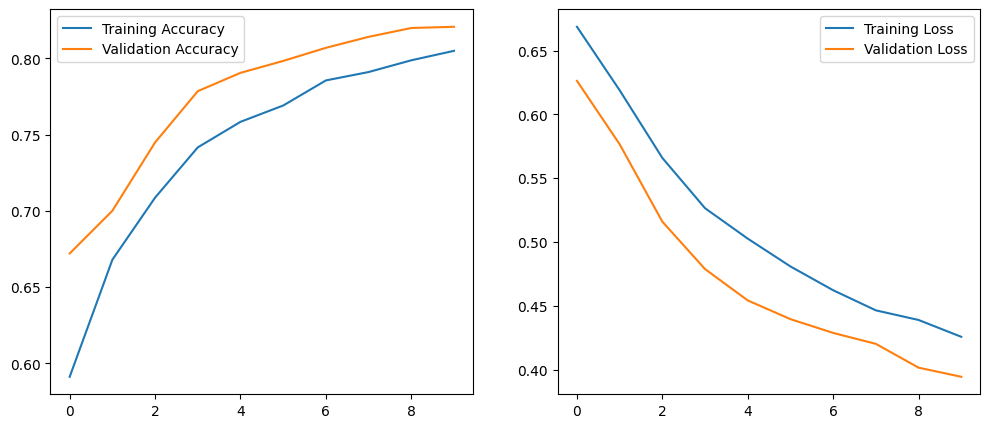

In [27]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()

plt.show()

### Error Analysis
Some misclassified images may contain unusual poses, low lighting, or heavy background clutter. In certain cases, close-up images of dog faces resemble cats, especially for small breeds. These examples highlight that the difficulty is influenced by intra-class variation and environmental noise rather than simply the number of classes.

### Final Reflection

This experiment demonstrated how convolutional neural networks progressively extract hierarchical features from raw pixels. Early layers capture simple edges, while deeper layers capture more abstract patterns. The results also show that dataset variability plays a major role in performance. Techniques such as data augmentation and dropout significantly improve generalization. Overall, this lab helped reinforce the importance of architecture design, regularization, and proper evaluation in image classification tasks.